# Generic Data download pipeline

In [1]:
import os
import glob
import time
import warnings
import logging

import numpy as np
import xarray as xr
import geopandas as gpd
import rioxarray                          
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cdsapi
import dask
import dask.array as da

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("ERA5Pipeline")

# ──────────────────────────────────────────────────────────────────────────────
class ERA5Pipeline:
    def __init__(
        self,
        variables: list,
        years,
        area: list,
        shapefile_path: str,
        output_dir: str = "era5_output",
        resolution: float = 2.0,
        time_step: str = "00:00",
        sleep_between_years: int = 5,
    ):
        self.variables          = variables
        self.years              = list(years)
        self.area               = area          # [N, W, S, E]
        self.shapefile_path     = shapefile_path
        self.output_dir         = output_dir
        self.resolution         = resolution
        self.time_step          = time_step
        self.sleep_between_years = sleep_between_years

        # paths
        self.raw_dir      = os.path.join(output_dir, "raw")
        self.regrid_dir   = os.path.join(output_dir, "regridded")
        self.merged_path  = os.path.join(output_dir, "era5_merged.nc")
        self.clipped_path = os.path.join(output_dir, "era5_clipped.nc")
        self.lat_grid = np.arange(area[2], area[0] + resolution, resolution)
        self.lon_grid = np.arange(area[1], area[3] + resolution, resolution)

        self._make_dirs()
        log.info("ERA5Pipeline initialised  |  variables=%s  years=%s",
                 variables, self.years)

    def _make_dirs(self):
        for d in [self.output_dir, self.raw_dir, self.regrid_dir]:
            os.makedirs(d, exist_ok=True)

    @staticmethod
    def _normalise_lon(ds, lon_name):
        """Wrap longitudes to [-180, 180] and sort."""
        ds = ds.assign_coords(
            {lon_name: ((ds[lon_name] + 180) % 360 - 180)}
        ).sortby(lon_name)
        return ds

    @staticmethod
    def _standardise_dims(ds, lat_name, lon_name):
        """Rename lat/lon/valid_time to canonical names."""
        rename = {}
        if lat_name != "lat":
            rename[lat_name] = "lat"
        if lon_name != "lon":
            rename[lon_name] = "lon"
        if "valid_time" in ds.dims or "valid_time" in ds.coords:
            rename["valid_time"] = "time"
        if rename:
            ds = ds.rename(rename)
        return ds

# ───────────────────────────────────── Download data ─────────────────────────────────────────
    def download(self):

        log.info("── Data ownload ──────────────────────────────────")
        client = cdsapi.Client()

        for y in self.years:
            raw_path = os.path.join(self.raw_dir, f"era5_{y}.nc")

            if os.path.exists(raw_path):
                log.info("  %d  already downloaded, skipping.", y)
                continue

            log.info("  Downloading %d …", y)

            client.retrieve(
                "reanalysis-era5-land",
                {
                    "variable": self.variables,
                    "year":     [str(y)],
                    "month":    [f"{m:02d}" for m in range(1, 13)],
                    "day":      [f"{d:02d}" for d in range(1, 32)],
                    "time":     [self.time_step],
                    "data_format": "netcdf",
                    "area":     self.area,
                    "download_format": "unarchived"
                },
                raw_path,
            )

            # ---- validating downloads ----
            try:
                ds_test = xr.open_dataset(raw_path)
                ds_test.close()

                log.info(f"  {y} verified ✔")

            except Exception as e:
                raise RuntimeError(f"❌ Download corrupted for year {y}: {e}\nCorrupted file detected: {raw_path}")
            
            log.info("  %d  saved → %s", y, raw_path)

            time.sleep(self.sleep_between_years)

        log.info("Download complete.")

# ───────────────────────────────────── Gridding to 2*   ─────────────────────────────────────────      
    def regrid(self):
        log.info("── Gridding to 2* ────────────────────────────────────")
        raw_files = sorted(glob.glob(os.path.join(self.raw_dir, "era5_*.nc")))

        if not raw_files:
            raise FileNotFoundError(
                f"No raw files found in {self.raw_dir}. Run download() first."
            )

        for raw_path in raw_files:
            year = os.path.basename(raw_path).replace("era5_", "").replace(".nc", "")
            out_path = os.path.join(self.regrid_dir, f"era5_{year}_2deg.nc")

            if os.path.exists(out_path):
                log.info("  %s  already regridded, skipping.", year)
                continue

            log.info("  Regridding %s …", year)

            ds = xr.open_dataset(raw_path)
            lat_name = "latitude" if "latitude" in ds.coords else "lat"
            lon_name = "longitude" if "longitude" in ds.coords else "lon"
            ds = self._normalise_lon(ds, lon_name)
            ds_2deg = ds.interp({lat_name: self.lat_grid, lon_name: self.lon_grid})
            ds_2deg = self._standardise_dims(ds_2deg, lat_name, lon_name)
            ds_2deg.to_netcdf(out_path)
            ds.close()
            ds_2deg.close()
            log.info("  %s  saved → %s", year, out_path)

        # ---- merging all year data ----
        log.info("  Merging all years → %s", self.merged_path)
        regrid_files = sorted(
            glob.glob(os.path.join(self.regrid_dir, "era5_*_2deg.nc"))
        )
        ds_all = xr.open_mfdataset(regrid_files, combine="by_coords")
        ds_all.to_netcdf(self.merged_path)
        ds_all.close()
        log.info("Regrid complete.")

# ───────────────────────────────────── Clip To USA MAP   ─────────────────────────────────────────      
    def clip(self):
        log.info("── Clipping ──────────────────────────────────────")

        if not os.path.exists(self.merged_path):
            raise FileNotFoundError(
                f"{self.merged_path} not found. Run regrid() first."
            )

        log.info("  Loading shapefile: %s", self.shapefile_path)
        gdf = gpd.read_file(self.shapefile_path).to_crs("EPSG:4326")

        gdf_dissolved = gdf.dissolve()

        log.info("  Opening merged dataset …")
        ds = xr.open_dataset(self.merged_path)
        ds = ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
        ds = ds.rio.write_crs("EPSG:4326")

        log.info("  Clipping …")
        ds_clip = ds.rio.clip(
            gdf_dissolved.geometry,
            gdf_dissolved.crs,
            drop=False,
            all_touched=True,
        )

        ds_clip.to_netcdf(self.clipped_path)
        ds.close()
        ds_clip.close()

        log.info("  Clipped dataset saved → %s", self.clipped_path)
        log.info("Clip complete.")

# ───────────────────────────────────── Plotting  ─────────────────────────────────────────      
    def plot(
        self,
        var_name: str = None,
        time_index: int = 0,
        cmap: str = "RdYlBu_r",
        save_path: str = None,
    ):
        log.info("── Plotting ──────────────────────────────────────")

        src = self.clipped_path if os.path.exists(self.clipped_path) else self.merged_path
        ds = xr.open_dataset(src)

        if var_name is None:
            valid_vars = [v for v in ds.data_vars if 'time' in ds[v].dims]
            if not valid_vars:
                valid_vars = [v for v in ds.data_vars if v != "spatial_ref"]
            
            var_name = valid_vars[0]
            log.info("  var_name not specified, using data variable '%s'.", var_name)
        # ------------------------------------

        da = ds[var_name]

        if "time" in da.dims:
            da = da.isel(time=time_index)
            ts = str(da.time.values)[:16]
        else:
            ts = "No time dim"

        fig = plt.figure(figsize=(7, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            cbar_kwargs={"label": f"{var_name}"},
        )

        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,   linestyle=":", linewidth=0.6)
        ax.add_feature(cfeature.STATES,    alpha=0.4,     linewidth=0.4)
        ax.set_extent(
            [self.area[1], self.area[3], self.area[2], self.area[0]],
            crs=ccrs.PlateCarree(),
        )
        plt.title(f"ERA5  |  {var_name}  |  {ts}", fontsize=13)
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            log.info("  Figure saved → %s", save_path)
        else:
            plt.show()

        ds.close()

# ───────────────────────────────────── Full pipeline run  ─────────────────────────────────────────      
    def run(self):
        self.download()
        self.regrid()
        self.clip()
        self.plot()
        log.info("Pipeline finished. Outputs in: %s", self.output_dir)

# Air Temp

18:59:48  INFO      ERA5Pipeline initialised  |  variables=['2m_temperature']  years=[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
18:59:48  INFO      ── Step 4: Plot ──────────────────────────────────────


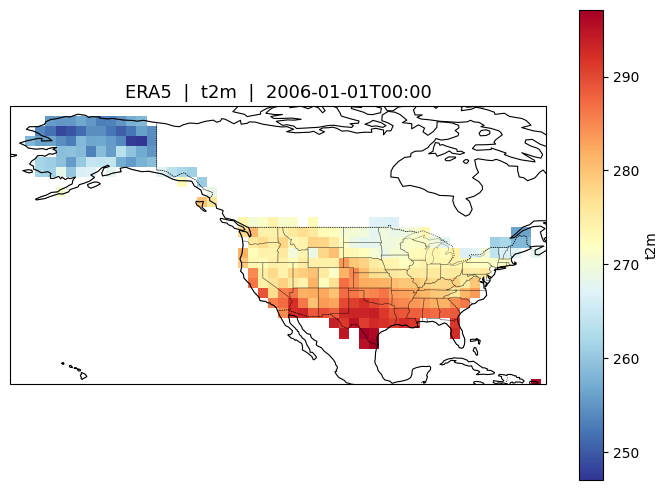

In [ ]:
# ── Temperature specs ────────────────
temp_pipeline = ERA5Pipeline(
    variables=[
        "2m_temperature",
    ],
    years=range(2006, 2022),
    area=[73, -170, 18, -64],                        # [N, W, S, E]
    shapefile_path=r"usa shape file\cb_2022_us_bg_500k.shp",
    output_dir="era5_temperature",
    resolution=2.0,
    time_step="00:00",
)
    
temp_pipeline.plot(var_name="t2m")

# Rainfall (ppt.)

19:55:04  INFO      ERA5Pipeline initialised  |  variables=['total_precipitation']  years=[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
19:55:04  INFO      ── Data ownload ──────────────────────────────────
19:55:06  INFO        Downloading 2006 …
2026-05-05 19:55:07,759 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
19:55:07  INFO      [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised ti

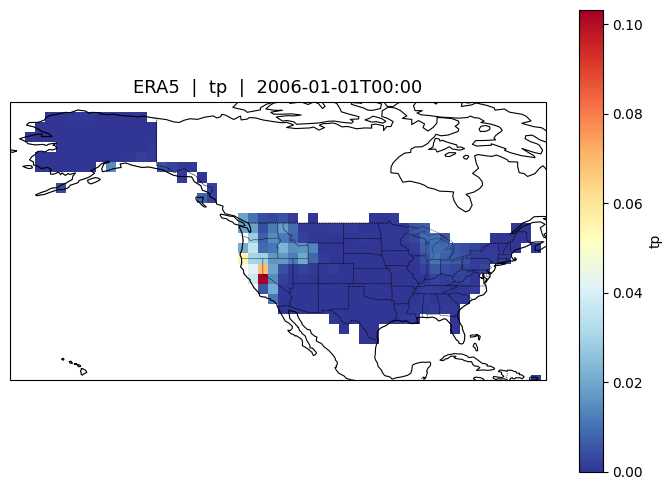

20:41:23  INFO      Pipeline finished. Outputs in: era5_total_ppt


In [ ]:
# ── Rainfall specs ────────────────
total_ppt = ERA5Pipeline(
    variables=[
        "total_precipitation",
    ],
    years=range(2006, 2022),
    area=[73, -170, 18, -64],                        # [N, W, S, E]
    shapefile_path=r"usa shape file\cb_2022_us_bg_500k.shp",
    output_dir="era5_total_ppt",
    resolution=2.0,
    time_step="00:00",
)

total_ppt.run()

# Soil temp

19:11:02  INFO      ERA5Pipeline initialised  |  variables=['soil_temperature_level_1']  years=[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
19:11:02  INFO      ── Data ownload ──────────────────────────────────
19:11:03  INFO        Downloading 2006 …
2026-05-05 19:11:04,013 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
19:11:04  INFO      [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimis

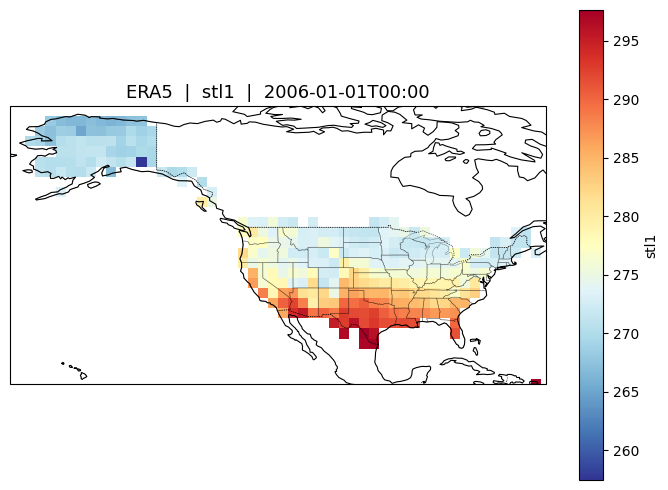

19:55:04  INFO      Pipeline finished. Outputs in: era5_soil_temperature


In [ ]:
# ── Soil Temperature specs ────────────────
soil_temp_pipeline = ERA5Pipeline(
    variables=[
        "soil_temperature_level_1",
    ],
    years=range(2006, 2022),
    area=[73, -170, 18, -64],                        # [N, W, S, E]
    shapefile_path=r"usa shape file\cb_2022_us_bg_500k.shp",
    output_dir="era5_soil_temperature",
    resolution=2.0,
    time_step="00:00",
)

soil_temp_pipeline.run()

# volumetric_soil_water_layer_1

18:28:55  INFO      ERA5Pipeline initialised  |  variables=['volumetric_soil_water_layer_1']  years=[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
18:28:55  INFO      ── Data ownload ──────────────────────────────────
18:28:57  INFO        2006  already downloaded, skipping.
18:28:57  INFO        2007  already downloaded, skipping.
18:28:57  INFO        2008  already downloaded, skipping.
18:28:57  INFO        2009  already downloaded, skipping.
18:28:57  INFO        2010  already downloaded, skipping.
18:28:57  INFO        2011  already downloaded, skipping.
18:28:57  INFO        2012  already downloaded, skipping.
18:28:57  INFO        2013  already downloaded, skipping.
18:28:57  INFO        2014  already downloaded, skipping.
18:28:57  INFO        2015  already downloaded, skipping.
18:28:57  INFO        2016  already downloaded, skipping.
18:28:57  INFO        2017  already downloaded, skipping.
18:28:57  INFO        2018  already 

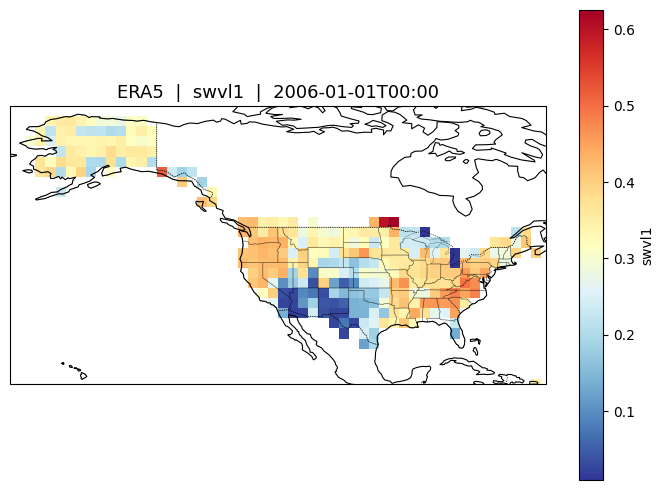

18:30:24  INFO      Pipeline finished. Outputs in: era5_soil_moisture


In [2]:
 # ── Soil Moisture specs ────────────────
soil_moist_pipeline = ERA5Pipeline(
    variables=[
        "volumetric_soil_water_layer_1",
    ],
    years=range(2006, 2022),
    area=[73, -170, 18, -64],                        # [N, W, S, E]
    shapefile_path=r"usa shape file\cb_2022_us_bg_500k.shp",
    output_dir="era5_soil_moisture",
    resolution=2.0,
    time_step="00:00",
)

soil_moist_pipeline.run()

# RH (2m_dewpoint_temperature)

22:56:03  INFO      ERA5Pipeline initialised  |  variables=['2m_dewpoint_temperature']  years=[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
22:56:03  INFO      ── Data ownload ──────────────────────────────────
22:56:04  INFO        Downloading 2006 …
2026-05-06 22:56:06,459 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
22:56:06  INFO      [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimise

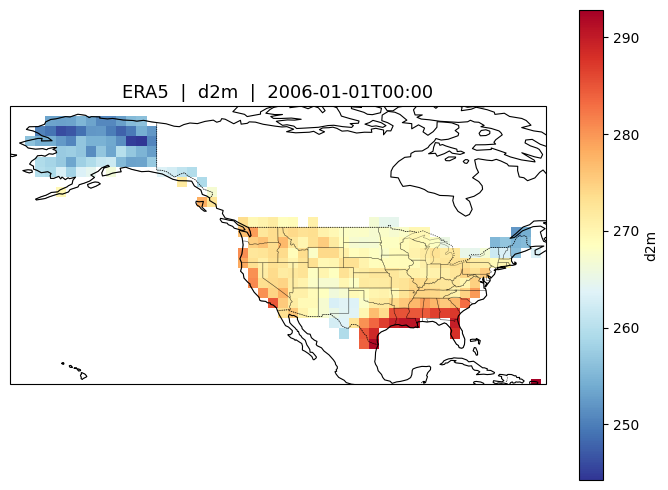

23:54:41  INFO      Pipeline finished. Outputs in: era5_dewtemperature


In [ ]:
soil_dewtemp_pipeline = ERA5Pipeline(
    variables=[
        "2m_dewpoint_temperature",
    ],
    years=range(2006, 2022),
    area=[73, -170, 18, -64],                        # [N, W, S, E]
    shapefile_path=r"usa shape file\cb_2022_us_bg_500k.shp",
    output_dir="era5_dewtemperature",
    resolution=2.0,
    time_step="00:00",
)

soil_dewtemp_pipeline.run()

Conversion to RH

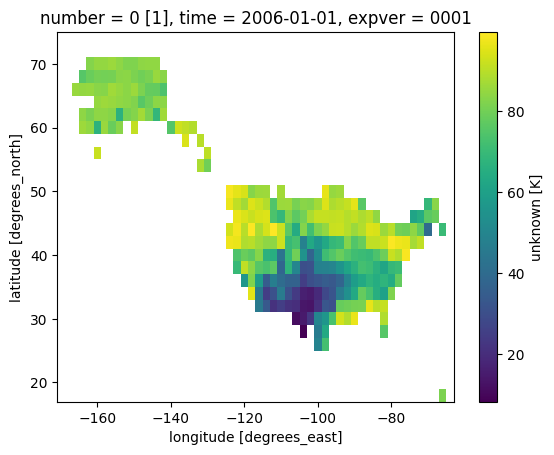

In [5]:
import xarray as xr
import numpy as np

# Load temperature dataset
ds_temp = xr.open_dataset(r"era5_temperature\era5_clipped.nc")

# Load dew point dataset
ds_dew = xr.open_dataset(r"era5_dewtemperature\era5_clipped.nc")

# Convert Kelvin → Celsius
T  = ds_temp["t2m"] - 273.15
Td = ds_dew["d2m"] - 273.15

# Compute Relative Humidity (%)
RH = 100 * (
    np.exp((17.625 * Td) / (243.04 + Td)) /
    np.exp((17.625 * T ) / (243.04 + T ))
)

# Restrict to physical range
RH = RH.clip(min=0, max=100)

# Create dataset
rh_ds = xr.Dataset({
    "relative_humidity": RH
})

# Save
rh_ds.to_netcdf("era5_relative_humidity.nc")

rh_ds["relative_humidity"].isel(time=0).plot()

In [9]:
print(rh_ds["relative_humidity"].min().values)
print(rh_ds["relative_humidity"].max().values)

1.5907139123433691
100.0
